# No-control random-initialization learning, then aligned controlled evaluation

This notebook learns the graph identifier from many **no-control** rollouts, each started from a fresh bounded random initial state.  
Each training repeat uses **one campaign only** for data collection.  
After learning, the **final learned model** is evaluated under control exactly as before:
- learned control
- oracle control
- no control

A dedicated sanity-check cell is included to inspect the training initial states and their coverage of the opinion range.

**Oracle-control fix:** evaluation uses aligned campaign behavior: learned, oracle, uniform, and anti-centrality controllers may all act at campaign 0 from the same `x0_eval`. Use `EVAL_ZERO_FIRST_CAMPAIGN=True` only for an explicit passive-first-campaign ablation.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

def get_dir_n_levels_up(path, n):
    for _ in range(n):
        path = os.path.dirname(path)
    return path

proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
if proj_root not in sys.path:
    sys.path.append(proj_root)

print("proj_root:", proj_root)

proj_root: d:\Work\repos\RL\unknown_graph_networks


In [3]:
# =========================================================
# Imports + helpers from modules
# =========================================================

import contextlib
import io
import time
from typing import Any
import copy

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)

from opinion_dynamics.identify_nonlinear import (
    GraphIdentifierEnv,
    pairs_from_intermediate,
    train_graph_identifier,
)
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control

import opinion_dynamics.experiments.online_nonlinear as online_nonlinear_mod
from opinion_dynamics.experiments.rollouts import (
    rollout_with_v,
    rollout_with_v_intermediate,
    make_env_with_dynamics,
    _fresh_env_from_template,
    sample_init_opinions,
    summarize_training_inits,
    waterfill_from_scores,
    uniform_budget_action,
    centrality_budget_action_from_state,
    apply_impulse_control,
    effective_adjacency_from_model_state,
    effective_centrality_from_model_state,
    rollout_with_model_derived_control_intermediate,
    rollout_with_policy_intermediate,
    rollout_with_uniform_intermediate,
    rollout_identifier_model_with_policy,
)
from opinion_dynamics.experiments.online_nonlinear import (
    run_repeated_nocontrol_singlecampaign_id_on_env,
    run_multi_seed_nocontrol_singlecampaign_experiment_dynamics,
    make_validation_x0_set,
    evaluate_model_on_validation_x0s,
    run_data_budget_sweep_on_env,
    run_multi_seed_data_budget_sweep,
)
from opinion_dynamics.experiments.metrics import (
    graph_sanity,
    add_trial_count_column,
    aggregate_learning_curve,
    estimate_trials_needed,
)
from opinion_dynamics.experiments.plots import (
    plot_impulse_node_trajectories,
    show_matrix_with_cell_grid,
    concat_intermediate,
    build_augmented_campaign_trajectory,
    plot_learning_curve_metric,
    plot_trials_needed_summary,
    _legend_outside,
    plot_mean_baseline_comparison,
)


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_72116\1296201958.py:13: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [4]:
# =========================================================
# Global experiment configuration
# Edit these here and the later cells will reuse them consistently.
# =========================================================

SEEDS = range(10)
SEED_TO_PLOT = 3

B_CAMPAIGN = 1.0
LEARN_NUM_CAMPAIGNS = 1
EVAL_NUM_CAMPAIGNS = 5
NUM_REPEATS = 100

# Aligned evaluation convention.
# Controlled policies act at campaign 0 from the common x0_eval.
# Set this True only for an explicit passive-first-campaign ablation.
EVAL_ZERO_FIRST_CAMPAIGN = False

# Data/init settings
INIT_MODE = "uniform"

# Fit settings for the nonlinear identifier
FIT_MAX_STEPS = 2_000
FIT_CHECK_EVERY = 1_000

# Kept as a global for consistency with other notebooks.
# In THIS single-campaign no-control notebook it is effectively unused,
# because the learning loop already fits once per repeat after collecting
# the one no-control rollout.
UPDATE_A_EACH_CAMPAIGN = False

DYNAMICS_LIST = [
    "laplacian",
    "coca",
    # "friedkinjohnsen",
    "hegselmannkrause",
    # "nonlinearinfluence",
    # "repulsion",
]

FIT_BY_DYNAMICS = {
    "laplacian": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=1e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "coca": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=512,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "friedkinjohnsen": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "hegselmannkrause": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "nonlinearinfluence": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
}

# Optional identifier overrides; threaded into GraphIdentifierEnv(...)
IDENTIFIER_KW = {}


# ---------------------------------------------------------
# Validation / data-requirement logging
# ---------------------------------------------------------
# The core experiment already validates the learned controller after each
# no-control training trial. These options make those learning curves explicit.
KEEP_PER_REPEAT_VALIDATION_LOGS = True

# Criteria used to estimate "how many trials are enough" from the logged curves.
# Edit these thresholds depending on how strict you want to be.
DATA_NEED_CRITERIA = {
    # Learned final mean should be within this absolute gap of oracle final mean.
    "mean_gap_to_oracle_end": ("<=", 0.02),
    # Learned final mean should at least match / beat uniform.
    "mean_gain_vs_uniform_end": (">=", 0.0),
}

# Optional richer sweep. This retrains once per seed/dynamics while evaluating on
# several validation initial states at selected trial budgets. It is more robust
# than the single-x0 online log, but costs more runtime, so it is off by default.
RUN_MULTI_X0_DATA_BUDGET_SWEEP = False
DATA_BUDGET_TRIAL_COUNTS = [1, 2, 3, 5, 10, 20, 50, 100]
DATA_BUDGET_VALIDATION_X0S = 8
DATA_BUDGET_SEEDS = list(SEEDS)
DATA_BUDGET_DYNAMICS_LIST = list(DYNAMICS_LIST)

# Keep imported experiment helpers synchronized with this notebook's configuration.
online_nonlinear_mod.EVAL_ZERO_FIRST_CAMPAIGN = EVAL_ZERO_FIRST_CAMPAIGN
online_nonlinear_mod.FIT_BY_DYNAMICS = FIT_BY_DYNAMICS
online_nonlinear_mod.IDENTIFIER_KW = IDENTIFIER_KW


In [5]:
# =========================================================
# Core experiment functions are imported from opinion_dynamics.experiments.online_nonlinear
# =========================================================


## Validation learning-curve utilities

These helpers turn the per-repeat validation rows into learning curves and estimate how many no-control trials are needed under editable performance criteria.

In [6]:
# =========================================================
# Validation learning-curve / data-need helpers are imported from modules
# =========================================================


## Optional: multi-validation-x0 data budget sweep

The online logs above validate on one held-out initial state per seed. This optional sweep evaluates each trial budget on several validation initial states, which is more robust for estimating data needs.

In [7]:
# =========================================================
# Optional robust data-budget sweep helpers are imported from modules
# =========================================================


=== Running laplacian | learn from no-control single-campaign random inits ===
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init

,seed,repeat,repeat_seed,dynamics,init_mode,learn_num_campaigns,eval_num_campaigns,N,train_pairs_total,v_L1_final,...,mean_err_avg,mean_err_max,vx_gap_to_oracle_end,vx_err_avg,vx_err_max,time_fit_inner,time_step_inner,fit_calls_inner,step_calls_inner,trial_count
0,0,99,1000000,laplacian,uniform,1,5,15,400,0.218817,...,2.624364e-03,3.619105e-03,3.935859e-03,2.732056e-03,3.935859e-03,0.006701,0.000038,1,1,100
1,1,99,1000001,laplacian,uniform,1,5,15,400,0.253856,...,4.059629e-03,6.988708e-03,5.177918e-03,2.661657e-03,5.177918e-03,0.005665,0.000044,1,1,100
2,2,99,1000002,laplacian,uniform,1,5,15,400,0.100443,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.005640,0.000043,1,1,100
3,3,99,1000003,laplacian,uniform,1,5,15,400,0.185068,...,4.638886e-11,8.689194e-11,3.291234e-11,3.303219e-11,4.613998e-11,0.006382,0.000042,1,1,100
4,4,99,1000004,laplacian,uniform,1,5,15,400,0.166799,...,8.417899e-04,1.937581e-03,2.972522e-03,1.409615e-03,2.972522e-03,0.007052,0.000043,1,1,100
5,5,99,1000005,laplacian,uniform,1,5,15,400,0.170846,...,6.951248e-04,2.111846e-03,4.472481e-04,9.169168e-04,2.395830e-03,0.006289,0.000038,1,1,100
6,6,99,1000006,laplacian,uniform,1,5,15,400,0.282878,...,3.182832e-03,7.326202e-03,8.549645e-03,3.995579e-03,8.549645e-03,0.010338,0.000054,1,1,100
7,7,99,1000007,laplacian,uniform,1,5,15,400,0.155905,...,1.304593e-03,2.022451e-03,2.044272e-03,1.667798e-03,2.740397e-03,0.007537,0.000045,1,1,100
8,8,99,1000008,laplacian,uniform,1,5,15,400,0.127582,...,4.938010e-04,1.310225e-03,1.044293e-03,3.871568e-04,1.044293e-03,0.006147,0.000044,1,1,100
9,9,99,1000009,laplacian,uniform,1,5,15,400,0.158032,...,2.791051e-03,3.856429e-03,3.346978e-03,2.953832e-03,3.872872e-03,0.006004,0.000044,1,1,100


=== Per-repeat validation log available as df_learning ===
Rows: 3000 | columns: 29


,seed,repeat,repeat_seed,dynamics,init_mode,learn_num_campaigns,eval_num_campaigns,N,train_pairs_total,v_L1_final,...,mean_err_avg,mean_err_max,vx_gap_to_oracle_end,vx_err_avg,vx_err_max,time_fit_inner,time_step_inner,fit_calls_inner,step_calls_inner,trial_count
0,0,0,10000,laplacian,uniform,1,5,15,4,0.536412,...,0.044221,0.084541,0.085812,0.045810,0.085812,2.532327,0.000164,1,1,1
1,0,1,20000,laplacian,uniform,1,5,15,8,0.536471,...,0.044221,0.084541,0.085812,0.045810,0.085812,0.004585,0.000106,1,1,2
2,0,2,30000,laplacian,uniform,1,5,15,12,0.514731,...,0.018401,0.030331,0.031425,0.019521,0.031425,1.774375,0.000047,1,1,3
3,0,3,40000,laplacian,uniform,1,5,15,16,0.514606,...,0.018401,0.030331,0.031425,0.019521,0.031425,0.003800,0.000117,1,1,4
4,0,4,50000,laplacian,uniform,1,5,15,20,0.445375,...,0.018542,0.030564,0.031047,0.019379,0.031047,1.955636,0.000049,1,1,5


=== Aggregate by dynamics (final repeat only) ===


dynamics                   coca  hegselmannkrause  laplacian
repeat         count  10.000000         10.000000  10.000000
               mean   99.000000         99.000000  99.000000
               std     0.000000          0.000000   0.000000
               min    99.000000         99.000000  99.000000
               25%    99.000000         99.000000  99.000000
...                         ...               ...        ...
time_fit_inner min     0.006356          0.006069   0.005640
               25%     0.006784          0.006199   0.006040
               50%     0.007138          0.006417   0.006336
               75%     0.008066          0.007242   0.006964
               max     0.009945          0.007953   0.010338

[72 rows x 3 columns]

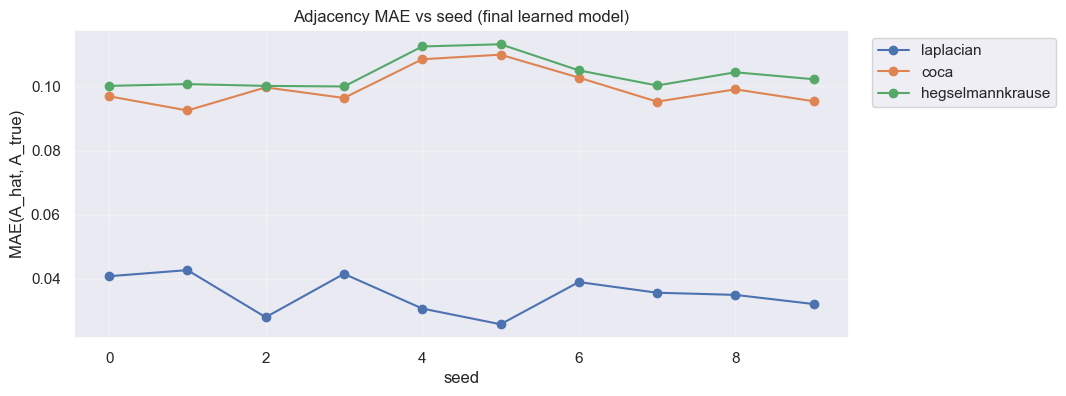

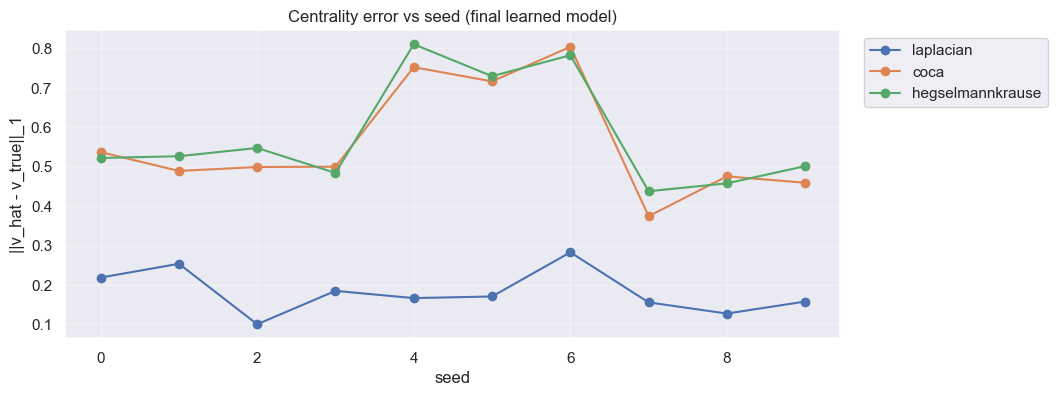

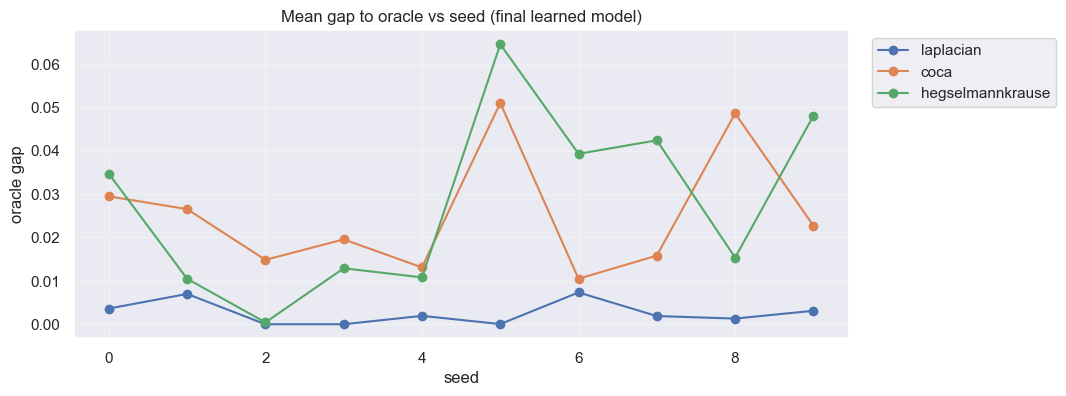

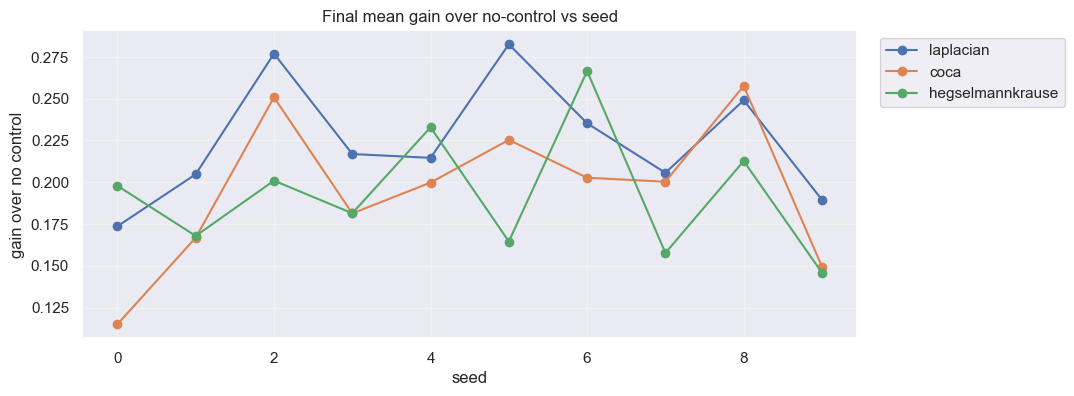

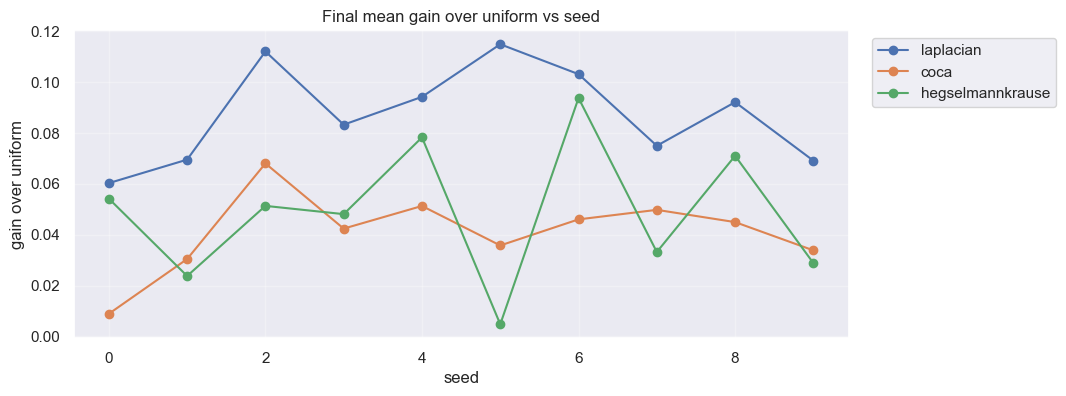

Per-repeat validation logs are available as df_learning and df_learning_by_dyn[dynamics].
Cached final models are available as final_models_by_dyn_seed[dynamics][seed].
Cached final artifacts are available as final_artifacts_by_dyn_seed[dynamics][seed].
Cached training initial states are available as train_x0s_by_dyn_seed[dynamics][seed].


In [8]:
# =========================================================
# Main experiment across propagation methods
# Learn from many one-campaign no-control rollouts.
# Evaluate final learned model under control.
# Cache ONLY the final resources needed downstream.
# =========================================================

final_models_by_dyn_seed = {}
final_metrics_by_dyn_seed = {}
final_artifacts_by_dyn_seed = {}
train_x0s_by_dyn_seed = {}
df_final_by_dyn = {}
df_learning_by_dyn = {}

dfs_final = []
dfs_learning = []

for dyn in DYNAMICS_LIST:
    print(f"=== Running {dyn} | learn from no-control single-campaign random inits ===")
    df_all, seed_cache = run_multi_seed_nocontrol_singlecampaign_experiment_dynamics(
        seeds=SEEDS,
        repeats_per_seed=NUM_REPEATS,
        dynamics_model=dyn,
        init_mode=INIT_MODE,
        learn_num_campaigns=LEARN_NUM_CAMPAIGNS,
        eval_num_campaigns=EVAL_NUM_CAMPAIGNS,
        B_campaign=B_CAMPAIGN,
        suppress_fit_logs=True,
        return_artifacts=True,
        identifier_kwargs=IDENTIFIER_KW,
        **FIT_BY_DYNAMICS[dyn],
    )

    # Keep the complete per-repeat validation log. This is the main learning curve:
    # one row per seed/repeat/dynamics, evaluated after each newly collected trial.
    df_all = add_trial_count_column(df_all)
    df_learning_by_dyn[dyn] = df_all.copy()
    dfs_learning.append(df_all.copy())

    final_models_by_dyn_seed[dyn] = {}
    final_metrics_by_dyn_seed[dyn] = {}
    final_artifacts_by_dyn_seed[dyn] = {}
    train_x0s_by_dyn_seed[dyn] = {}

    for seed in SEEDS:
        seed_out = seed_cache[int(seed)]
        final_models_by_dyn_seed[dyn][int(seed)] = seed_out["model_final"]
        final_metrics_by_dyn_seed[dyn][int(seed)] = seed_out["final_row"]
        final_artifacts_by_dyn_seed[dyn][int(seed)] = seed_out["final_artifact"]
        train_x0s_by_dyn_seed[dyn][int(seed)] = seed_out["train_x0s"]

    # We only keep the final repeat per seed for downstream summaries.
    df_final = (
        df_all.sort_values(["seed", "repeat"])
        .groupby("seed", as_index=False, group_keys=False)
        .tail(1)
        .reset_index(drop=True)
    )
    df_final_by_dyn[dyn] = df_final
    dfs_final.append(df_final)

    # Drop bulky intermediate objects as soon as possible.
    del seed_cache
    del df_all

df = pd.concat(dfs_final, axis=0).reset_index(drop=True)
df_learning = pd.concat(dfs_learning, axis=0).reset_index(drop=True)

display(df)

print("=== Per-repeat validation log available as df_learning ===")
print("Rows:", len(df_learning), "| columns:", len(df_learning.columns))
display(df_learning.head())

print("=== Aggregate by dynamics (final repeat only) ===")
cols = [
    "repeat",
    "train_pairs_total",
    "v_L1_final",
    "A_MAE_final",
    "mean_gap_to_oracle_end",
    "mean_gain_vs_noc_end",
    "mean_gain_vs_uniform_end",
    "vx_gap_to_oracle_end",
    "time_fit_inner",
]
display(df.groupby("dynamics")[cols].describe().T)

for metric, ylabel, title in [
    ("A_MAE_final", "MAE(A_hat, A_true)", "Adjacency MAE vs seed (final learned model)"),
    ("v_L1_final", "||v_hat - v_true||_1", "Centrality error vs seed (final learned model)"),
    ("mean_gap_to_oracle_end", "oracle gap", "Mean gap to oracle vs seed (final learned model)"),
    ("mean_gain_vs_noc_end", "gain over no control", "Final mean gain over no-control vs seed"),
    ("mean_gain_vs_uniform_end", "gain over uniform", "Final mean gain over uniform vs seed"),
]:
    plt.figure(figsize=(10, 4))
    for dyn in DYNAMICS_LIST:
        sub = df[df["dynamics"] == dyn].sort_values("seed")
        plt.plot(sub["seed"], sub[metric], marker="o", label=dyn)
    plt.xlabel("seed")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

print("Per-repeat validation logs are available as df_learning and df_learning_by_dyn[dynamics].")
print("Cached final models are available as final_models_by_dyn_seed[dynamics][seed].")
print("Cached final artifacts are available as final_artifacts_by_dyn_seed[dynamics][seed].")
print("Cached training initial states are available as train_x0s_by_dyn_seed[dynamics][seed].")


## Validation learning curves: how many no-control trials are enough?

This cell uses `df_learning`, which now stores validation metrics after each training trial. The criteria are editable in `DATA_NEED_CRITERIA`.

Validation rows: 3000
One row = one dynamics/seed/repeat validation checkpoint.


,dynamics,trial_count,mean_gap_to_oracle_end_mean,mean_gap_to_oracle_end_std,mean_gap_to_oracle_end_count,mean_gain_vs_uniform_end_mean,mean_gain_vs_uniform_end_std,mean_gain_vs_uniform_end_count,mean_gain_vs_noc_end_mean,mean_gain_vs_noc_end_std,...,A_MAE_final_std,A_MAE_final_count,v_L1_final_mean,v_L1_final_std,v_L1_final_count,mean_gap_to_oracle_end_sem,mean_gain_vs_uniform_end_sem,mean_gain_vs_noc_end_sem,A_MAE_final_sem,v_L1_final_sem
0,coca,1,0.031374,0.017219,10,0.034976,0.017575,10,0.188789,0.044122,...,0.005462,10,0.576006,0.146908,10,0.005445,0.005558,0.013953,0.001727,0.046457
1,coca,2,0.031352,0.017208,10,0.034998,0.017527,10,0.188811,0.044077,...,0.005464,10,0.575978,0.146907,10,0.005442,0.005543,0.013938,0.001728,0.046456
2,coca,3,0.031352,0.017208,10,0.034998,0.017527,10,0.188811,0.044077,...,0.005465,10,0.575899,0.146883,10,0.005442,0.005543,0.013938,0.001728,0.046448
3,coca,4,0.031352,0.017208,10,0.034998,0.017527,10,0.188811,0.044077,...,0.005467,10,0.575818,0.146874,10,0.005442,0.005543,0.013938,0.001729,0.046446
4,coca,5,0.031318,0.017222,10,0.035032,0.017519,10,0.188845,0.044041,...,0.005468,10,0.575714,0.146869,10,0.005446,0.005540,0.013927,0.001729,0.046444
5,coca,6,0.031066,0.016899,10,0.035284,0.017639,10,0.189097,0.044461,...,0.005469,10,0.575608,0.146858,10,0.005344,0.005578,0.014060,0.001730,0.046440
6,coca,7,0.030435,0.016698,10,0.035915,0.016284,10,0.189728,0.043174,...,0.005471,10,0.575489,0.146823,10,0.005280,0.005149,0.013653,0.001730,0.046429
7,coca,8,0.030435,0.016698,10,0.035915,0.016284,10,0.189728,0.043174,...,0.005474,10,0.575341,0.146795,10,0.005280,0.005149,0.013653,0.001731,0.046421
8,coca,9,0.030418,0.016713,10,0.035932,0.016298,10,0.189745,0.043178,...,0.005476,10,0.575202,0.146791,10,0.005285,0.005154,0.013654,0.001732,0.046419
9,coca,10,0.030418,0.016713,10,0.035932,0.016298,10,0.189745,0.043178,...,0.005478,10,0.575063,0.146736,10,0.005285,0.005154,0.013654,0.001732,0.046402


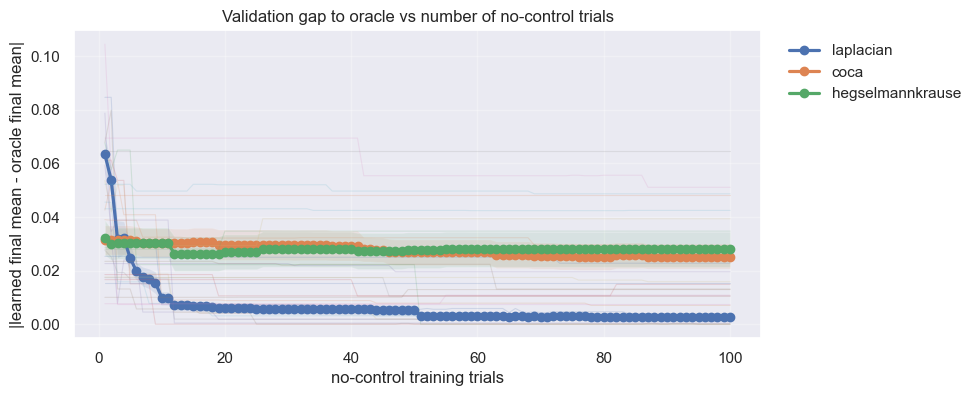

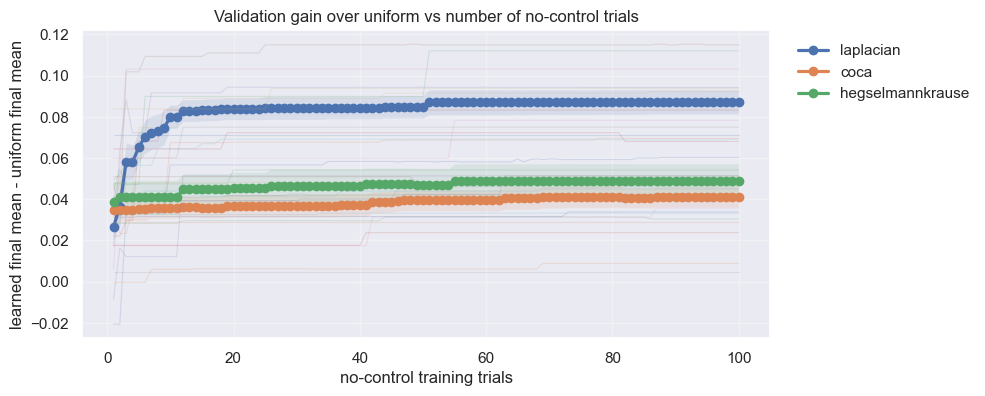

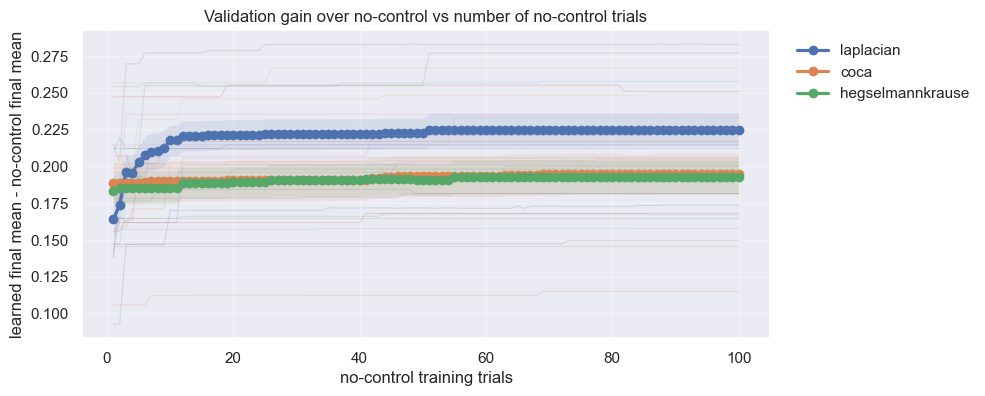

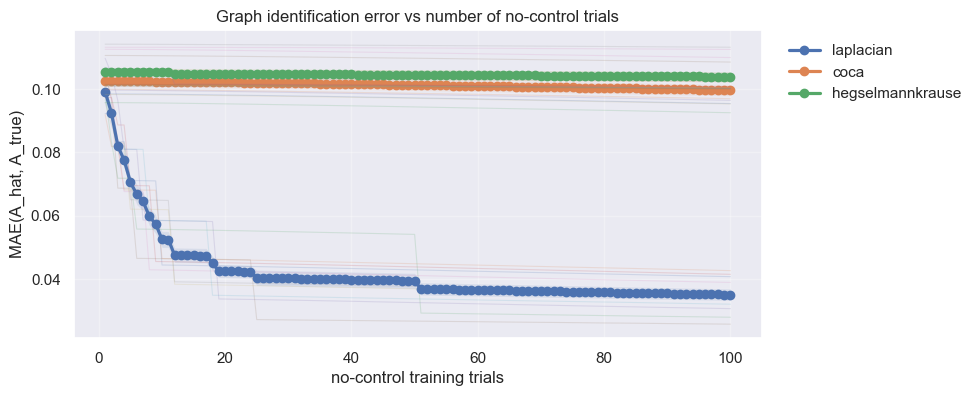

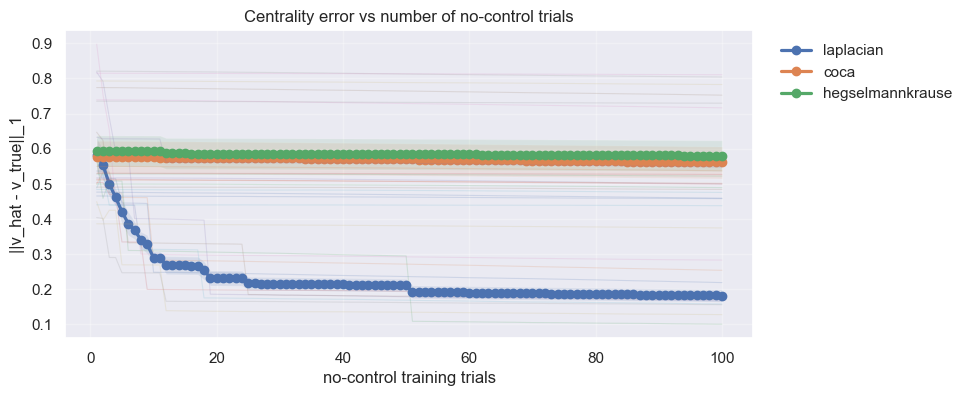

=== Data-need criteria ===
mean_gap_to_oracle_end <= 0.02
mean_gain_vs_uniform_end >= 0.0
=== First satisfying trial per seed ===


,dynamics,seed,trials_needed,train_pairs_needed,reached,mean_gap_to_oracle_end_at_last,mean_gain_vs_uniform_end_at_last,mean_gap_to_oracle_end_at_hit,mean_gain_vs_uniform_end_at_hit
0,coca,0,NaN,NaN,False,0.029486,0.008879,NaN,NaN
1,coca,1,NaN,NaN,False,0.026527,0.030424,NaN,NaN
2,coca,2,1.0,4.0,True,NaN,NaN,0.018488,0.064387
3,coca,3,47.0,188.0,True,NaN,NaN,0.019564,0.042392
4,coca,4,63.0,252.0,True,NaN,NaN,0.013100,0.051293
5,coca,5,NaN,NaN,False,0.051004,0.035760,NaN,NaN
6,coca,6,1.0,4.0,True,NaN,NaN,0.017351,0.039158
7,coca,7,1.0,4.0,True,NaN,NaN,0.017573,0.048028
8,coca,8,NaN,NaN,False,0.048595,0.044946,NaN,NaN
9,coca,9,NaN,NaN,False,0.022717,0.033828,NaN,NaN


=== Data need summary across seeds ===


,dynamics,seeds_total,seeds_reached,hit_rate,trials_needed_mean,trials_needed_median,trials_needed_p90,pairs_needed_median
0,coca,10,5,0.5,22.6,1.0,56.6,4.0
1,hegselmannkrause,10,5,0.5,3.2,1.0,7.6,4.0
2,laplacian,10,10,1.0,9.6,4.0,14.1,16.0


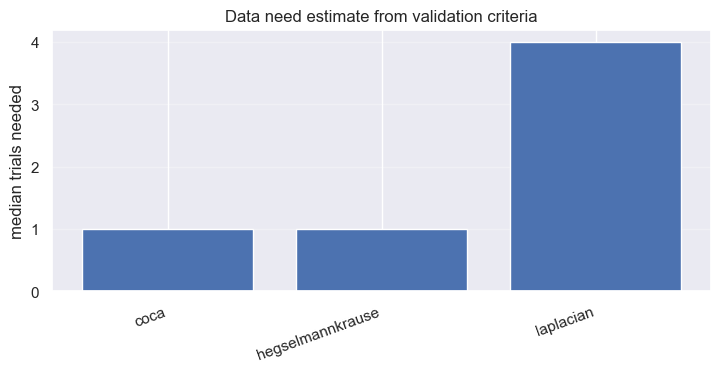

In [9]:
# =========================================================
# Analyze validation performance as a function of training data
# =========================================================

if "df_learning" not in globals():
    raise RuntimeError("Run the main experiment cell first so df_learning is available.")

print("Validation rows:", len(df_learning))
print("One row = one dynamics/seed/repeat validation checkpoint.")

learning_metrics = [
    "mean_gap_to_oracle_end",
    "mean_gain_vs_uniform_end",
    "mean_gain_vs_noc_end",
    "A_MAE_final",
    "v_L1_final",
]
learning_metrics = [m for m in learning_metrics if m in df_learning.columns]

curve_summary = aggregate_learning_curve(df_learning, metrics=learning_metrics)
display(curve_summary.head(20))

for metric, ylabel, title in [
    (
        "mean_gap_to_oracle_end",
        "|learned final mean - oracle final mean|",
        "Validation gap to oracle vs number of no-control trials",
    ),
    (
        "mean_gain_vs_uniform_end",
        "learned final mean - uniform final mean",
        "Validation gain over uniform vs number of no-control trials",
    ),
    (
        "mean_gain_vs_noc_end",
        "learned final mean - no-control final mean",
        "Validation gain over no-control vs number of no-control trials",
    ),
    (
        "A_MAE_final",
        "MAE(A_hat, A_true)",
        "Graph identification error vs number of no-control trials",
    ),
    (
        "v_L1_final",
        "||v_hat - v_true||_1",
        "Centrality error vs number of no-control trials",
    ),
]:
    if metric in df_learning.columns:
        plot_learning_curve_metric(df_learning, metric, ylabel=ylabel, title=title)

print("=== Data-need criteria ===")
for metric, (op, threshold) in DATA_NEED_CRITERIA.items():
    print(f"{metric} {op} {threshold}")

trials_needed_by_seed, trials_needed_summary = estimate_trials_needed(
    df_learning,
    DATA_NEED_CRITERIA,
)

print("=== First satisfying trial per seed ===")
display(trials_needed_by_seed.sort_values(["dynamics", "seed"]))

print("=== Data need summary across seeds ===")
display(trials_needed_summary.sort_values("dynamics"))
plot_trials_needed_summary(trials_needed_summary.sort_values("dynamics"))


## Optional robust sweep runner

Set `RUN_MULTI_X0_DATA_BUDGET_SWEEP = True` in the config cell to run this. It is intentionally separate from the default path because it retrains/evaluates additional validation initial states.

In [10]:
# =========================================================
# Optional: run the multi-validation-x0 data-budget sweep
# =========================================================

if RUN_MULTI_X0_DATA_BUDGET_SWEEP:
    df_data_budget = run_multi_seed_data_budget_sweep(
        seeds=DATA_BUDGET_SEEDS,
        dynamics_list=DATA_BUDGET_DYNAMICS_LIST,
        trial_counts=DATA_BUDGET_TRIAL_COUNTS,
        n_validation_x0=DATA_BUDGET_VALIDATION_X0S,
        init_mode=INIT_MODE,
        learn_num_campaigns=LEARN_NUM_CAMPAIGNS,
        eval_num_campaigns=EVAL_NUM_CAMPAIGNS,
        B_campaign=B_CAMPAIGN,
        device="cpu",
    )
    display(df_data_budget)

    for metric, ylabel, title in [
        ("mean_gap_to_oracle_end", "validation-set gap to oracle", "Multi-x0 validation gap to oracle"),
        ("mean_gain_vs_uniform_end", "validation-set gain over uniform", "Multi-x0 validation gain over uniform"),
        ("A_MAE_final", "MAE(A_hat, A_true)", "Multi-x0 sweep: graph error"),
        ("v_L1_final", "||v_hat - v_true||_1", "Multi-x0 sweep: centrality error"),
    ]:
        if metric in df_data_budget.columns:
            plot_learning_curve_metric(df_data_budget, metric, ylabel=ylabel, title=title, show_seed_traces=True)

    budget_needed_by_seed, budget_needed_summary = estimate_trials_needed(
        df_data_budget,
        DATA_NEED_CRITERIA,
    )
    display(budget_needed_by_seed.sort_values(["dynamics", "seed"]))
    display(budget_needed_summary.sort_values("dynamics"))
else:
    print("Skipped multi-x0 data-budget sweep. Set RUN_MULTI_X0_DATA_BUDGET_SWEEP = True to run it.")


Skipped multi-x0 data-budget sweep. Set RUN_MULTI_X0_DATA_BUDGET_SWEEP = True to run it.


In [11]:
# =========================================================
# Single-seed detailed runs for ALL dynamics
# Reuse the cached FINAL outputs from the main experiment cell.
# Uses local variables so notebook-wide config is not overwritten.
# =========================================================

seed_to_plot = int(globals().get("SEED_TO_PLOT"))
num_repeats_local = int(globals().get("NUM_REPEATS"))
dynamics_list_local = list(globals().get("DYNAMICS_LIST"))

outs_by_dyn = {}
metrics_by_dyn = {}
art_by_dyn = {}
model_by_dyn = {}

for dyn_name in dynamics_list_local:
    print("\n" + "=" * 80)
    print(f"=== DYNAMICS: {dyn_name} | SEED {seed_to_plot} ===")
    print("=" * 80)

    metrics = final_metrics_by_dyn_seed[dyn_name][int(seed_to_plot)]
    art = final_artifacts_by_dyn_seed[dyn_name][int(seed_to_plot)]
    model = final_models_by_dyn_seed[dyn_name][int(seed_to_plot)]
    train_x0s = train_x0s_by_dyn_seed[dyn_name][int(seed_to_plot)]

    outs_by_dyn[dyn_name] = {
        "train_x0s": train_x0s,
        "x0_eval": art["x0_eval"],
    }
    metrics_by_dyn[dyn_name] = metrics
    art_by_dyn[dyn_name] = art
    model_by_dyn[dyn_name] = model

    print(f"=== FINAL REPEAT {metrics['repeat'] + 1}/{num_repeats_local} ===")
    print(f"train_pairs_total: {metrics['train_pairs_total']}")
    print("=== METRICS ===")
    for k, v in metrics.items():
        print(f"{k}: {v}")



=== DYNAMICS: laplacian | SEED 3 ===
=== FINAL REPEAT 100/100 ===
train_pairs_total: 400
=== METRICS ===
seed: 3
repeat: 99
repeat_seed: 1000003
dynamics: laplacian
init_mode: uniform
learn_num_campaigns: 1
eval_num_campaigns: 5
N: 15
train_pairs_total: 400
v_L1_final: 0.1850676158380502
A_Fro_final: 0.9222555378139449
A_MAE_final: 0.04148241565809166
mean_oracle_end: 0.7588969121419051
mean_learn_end: 0.7588969121063179
mean_noc_end: 0.5419949435982832
mean_uniform_end: 0.6756199355335678
mean_gap_to_oracle_end: 3.558719985363723e-11
mean_gain_vs_noc_end: 0.21690196850803478
mean_gain_vs_uniform_end: 0.08327697657275013
mean_err_avg: 4.6388855719688614e-11
mean_err_max: 8.689193808919526e-11
vx_gap_to_oracle_end: 3.291233952040784e-11
vx_err_avg: 3.3032188095916126e-11
vx_err_max: 4.6139980725001806e-11
time_fit_inner: 0.0063819000497460365
time_step_inner: 4.220008850097656e-05
fit_calls_inner: 1
step_calls_inner: 1

=== DYNAMICS: coca | SEED 3 ===
=== FINAL REPEAT 100/100 ===
train


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: laplacian ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

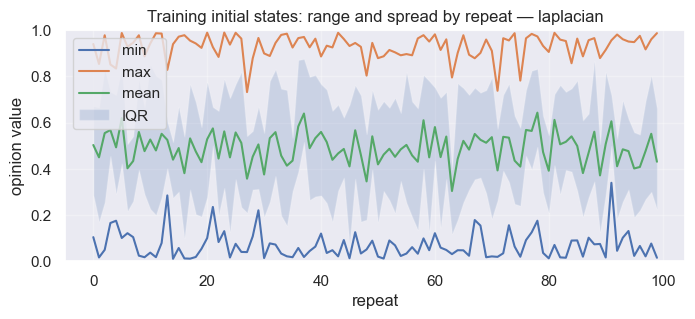

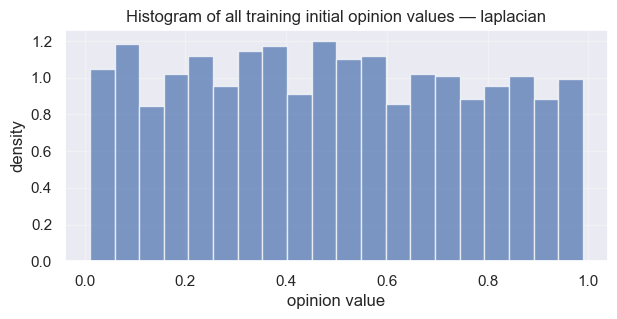

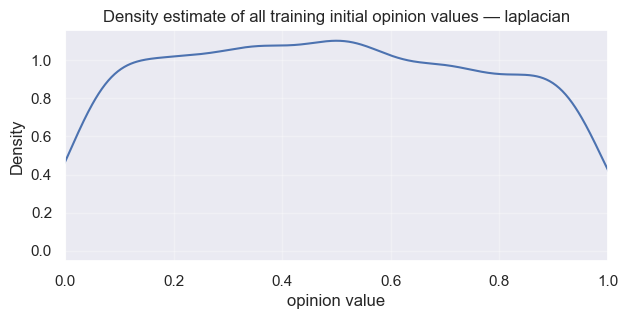

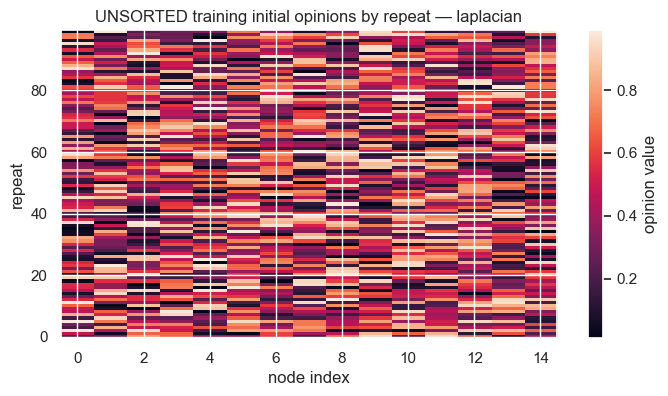

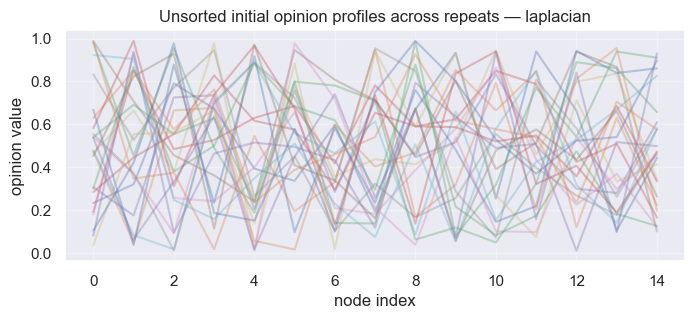


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: coca ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

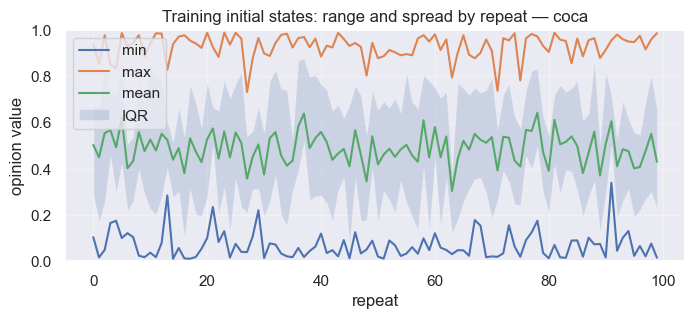

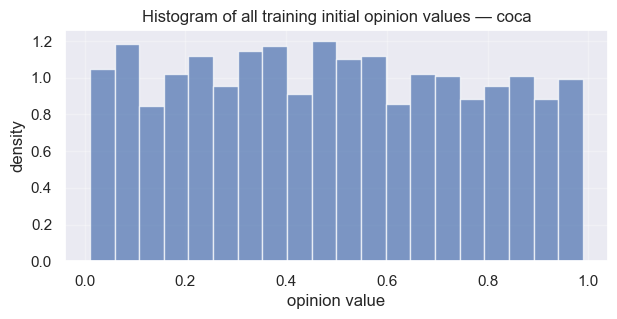

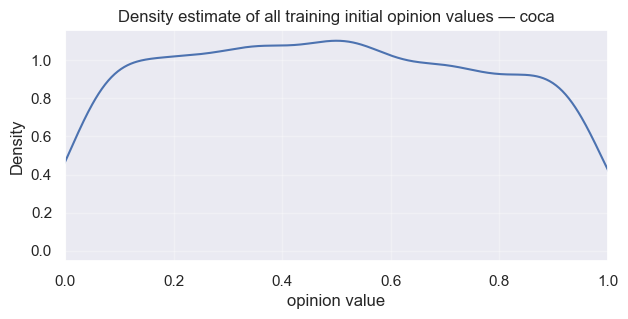

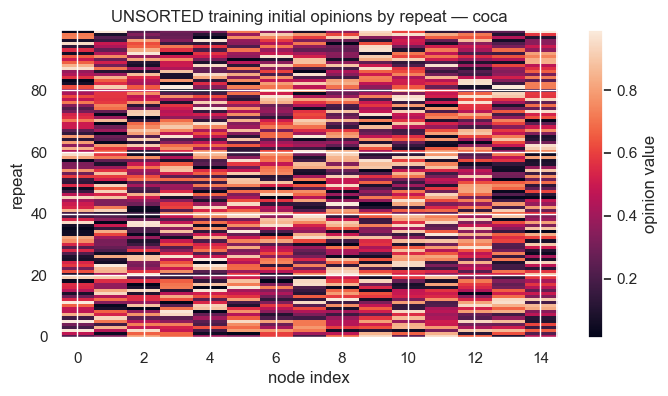

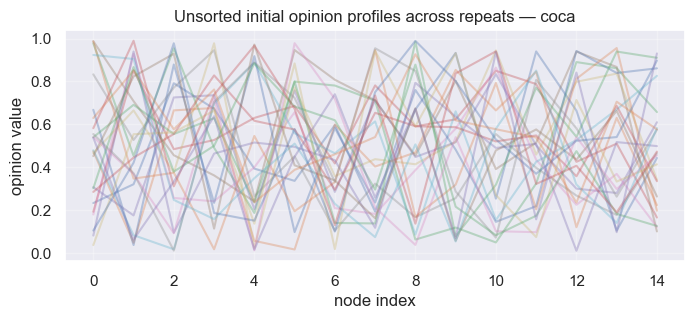


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: hegselmannkrause ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

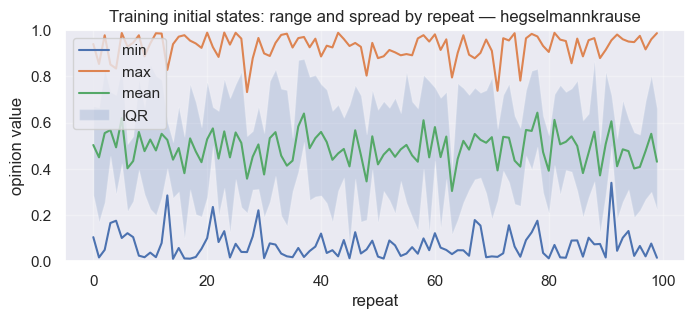

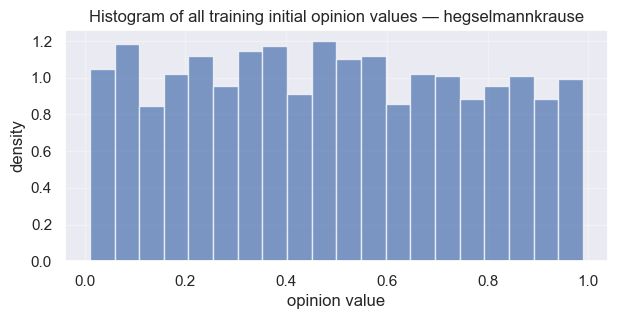

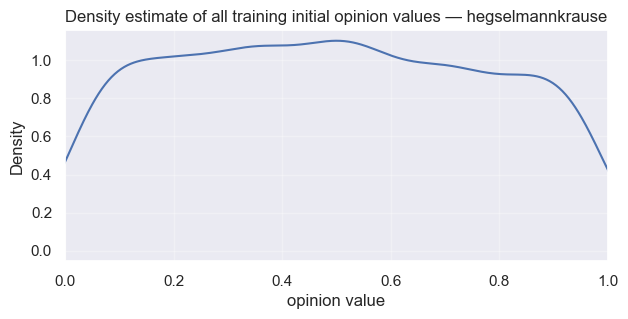

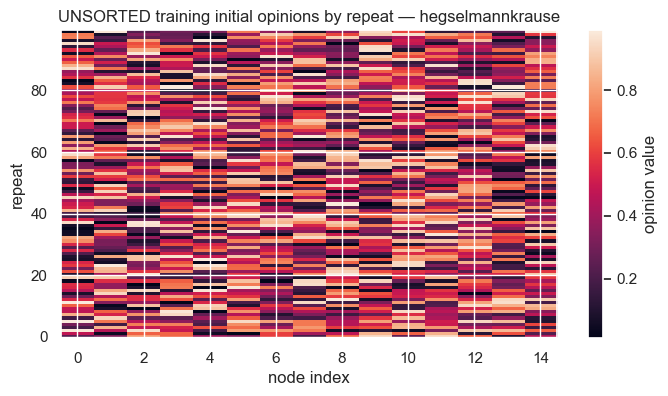

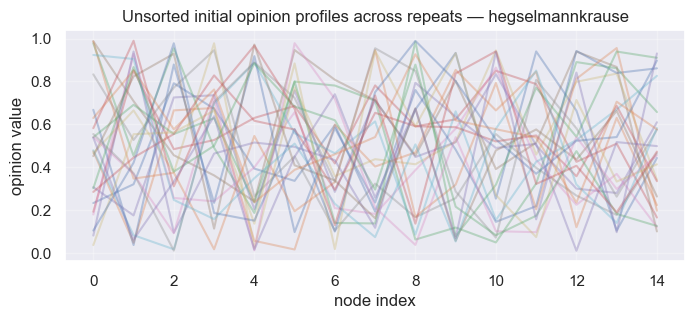

In [12]:
# =========================================================
# Sanity check: inspect the training initial states
# NOTE: uses the globally configured INIT_MODE and the cached train_x0s for the selected seed.
# =========================================================

for DYNAMICS in list(art_by_dyn.keys()):
    out = outs_by_dyn[DYNAMICS]
    all_x0_train = np.asarray(out["train_x0s"], dtype=float)
    summary_df = summarize_training_inits(all_x0_train)

    print("\n" + "-" * 80)
    print(f"=== TRAINING-INIT SANITY: {DYNAMICS} ===")
    print("-" * 80)
    display(summary_df.describe().T)

    flat = all_x0_train.ravel()
    print("Overall value summary:")
    display(pd.Series(flat).describe())

    plt.figure(figsize=(8, 3))
    plt.plot(summary_df["repeat"], summary_df["min"], label="min")
    plt.plot(summary_df["repeat"], summary_df["max"], label="max")
    plt.plot(summary_df["repeat"], summary_df["mean"], label="mean")
    plt.fill_between(summary_df["repeat"], summary_df["q25"], summary_df["q75"], alpha=0.2, label="IQR")
    plt.title(f"Training initial states: range and spread by repeat — {DYNAMICS}")
    plt.xlabel("repeat")
    plt.ylabel("opinion value")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.hist(flat, bins=20, density=True, alpha=0.7)
    plt.title(f"Histogram of all training initial opinion values — {DYNAMICS}")
    plt.xlabel("opinion value")
    plt.ylabel("density")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 3))
    pd.Series(flat).plot(kind="density")
    plt.title(f"Density estimate of all training initial opinion values — {DYNAMICS}")
    plt.xlabel("opinion value")
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.imshow(all_x0_train, aspect="auto", origin="lower")
    plt.colorbar(label="opinion value")
    plt.title(f"UNSORTED training initial opinions by repeat — {DYNAMICS}")
    plt.xlabel("node index")
    plt.ylabel("repeat")
    plt.show()

    plt.figure(figsize=(8, 3))
    for r in range(min(all_x0_train.shape[0], 25)):
        plt.plot(all_x0_train[r], alpha=0.35)
    plt.title(f"Unsorted initial opinion profiles across repeats — {DYNAMICS}")
    plt.xlabel("node index")
    plt.ylabel("opinion value")
    plt.grid(True, alpha=0.3)
    plt.show()


=== DETAILED ANALYSIS: laplacian | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999999194405973
row_sum_mean: 1.0000000273653618
row_sum_max: 1.000000077765435
asym: 0.7822060514853054
edges: 210
sink_sizes: [15]
has_singleton_sink: False


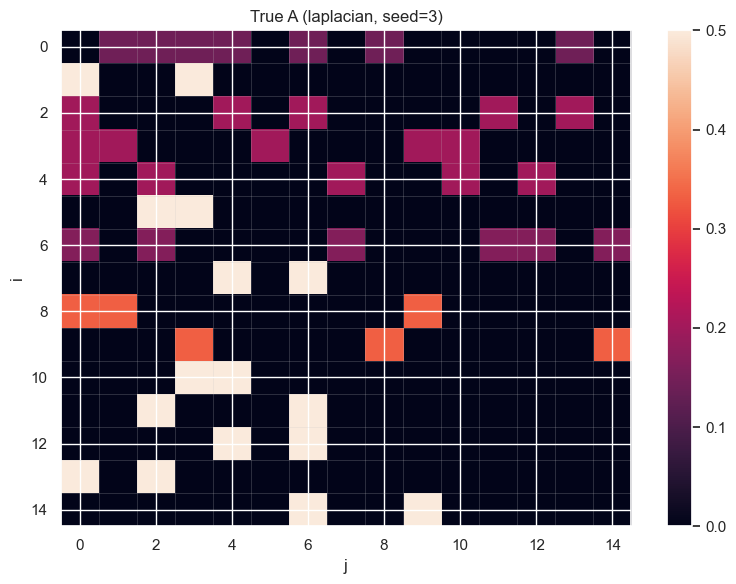

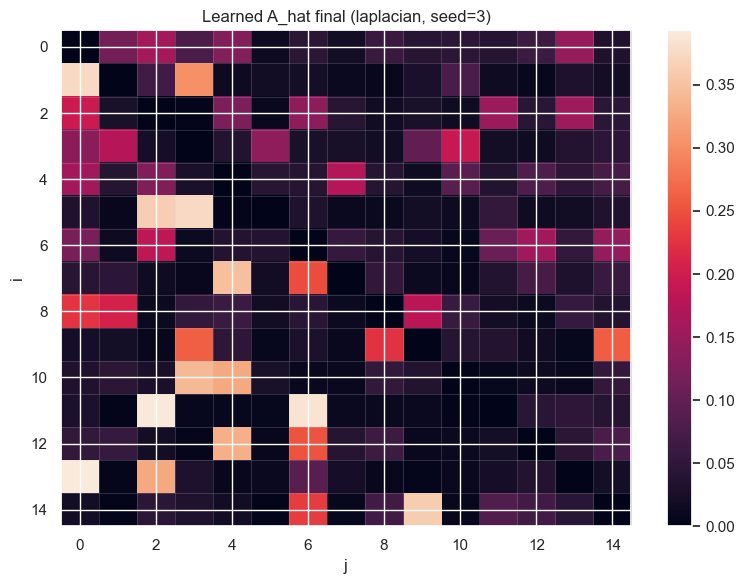


=== AUGMENTED TIME GRID CHECK ===
dt/t_s=0.5, t_campaign=2.0, campaigns=5
learned: T[0], T[-1], monotone: 0.0 10.0 True
oracle : T[0], T[-1], monotone: 0.0 10.0 True
expected final campaign time: 10.0


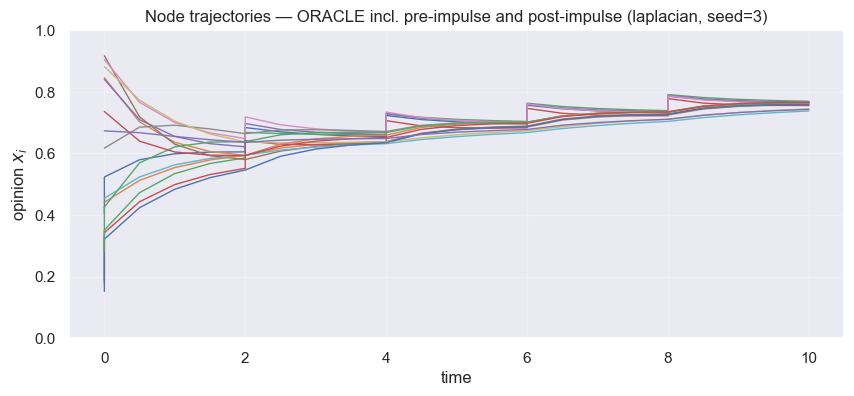

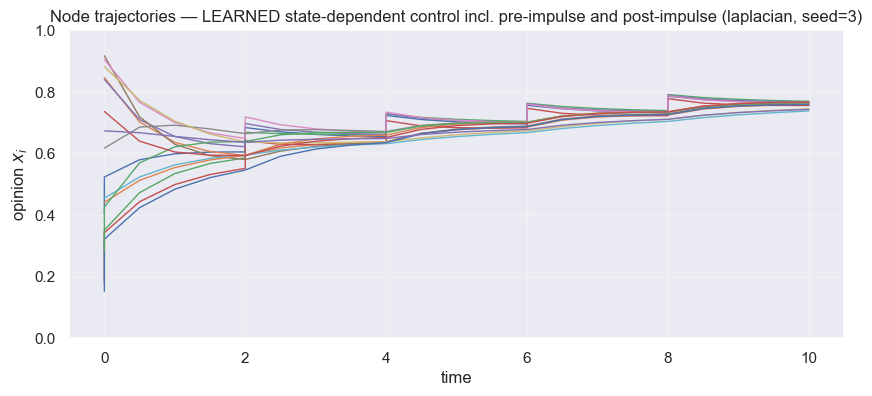


=== FAIRNESS CONVENTION ===
EVAL_ZERO_FIRST_CAMPAIGN: False
campaign-0 action sums: learned= 1.0 oracle= 1.0 uniform= 0.9999999999999999 nocontrol= 0.0
campaign-0 action L_inf learned-oracle: 1.4901161193847656e-08

=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.1850676158380502
L1(v_eff at campaign 0 - v_true): 0.17988406996548112


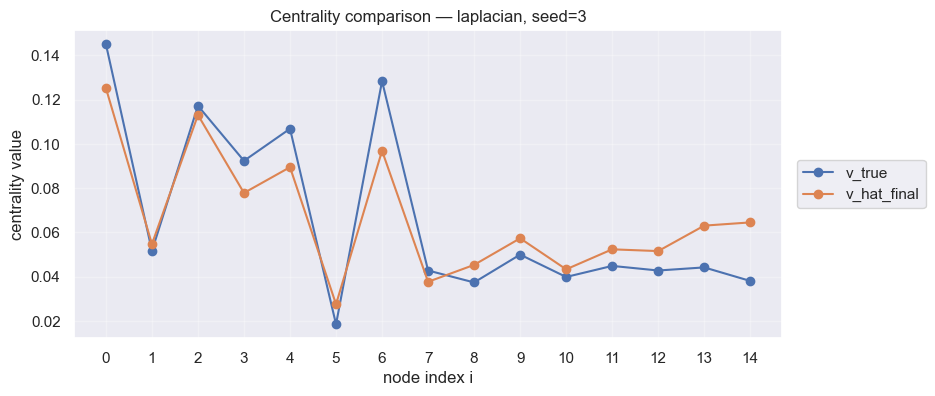

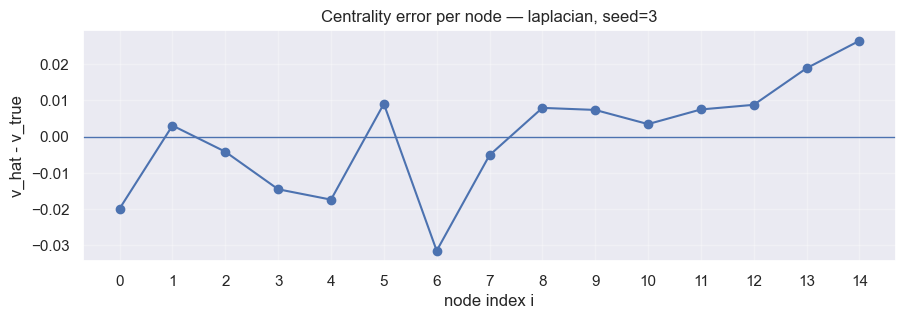

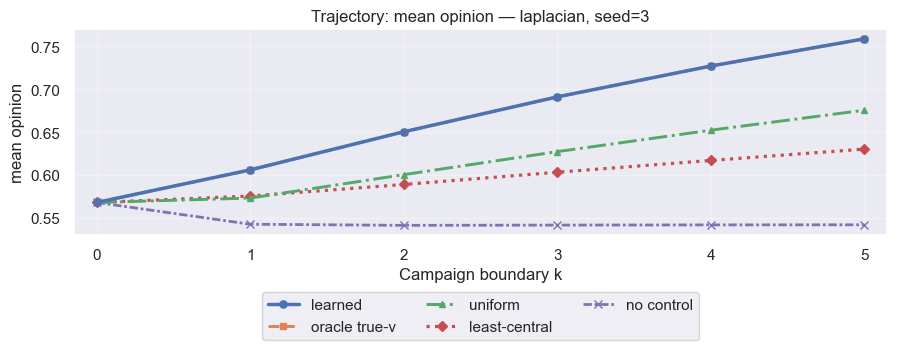


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 2.150702838044083e-09
learned states[1] vs nocontrol states[1] L_inf: 0.09078837150428198
learned final mean vs uniform final mean: 0.08327697657275013

=== DETAILED ANALYSIS: coca | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999999143183231
row_sum_mean: 0.9999999880169829
row_sum_max: 1.000000087544322
asym: 0.549774277466638
edges: 21

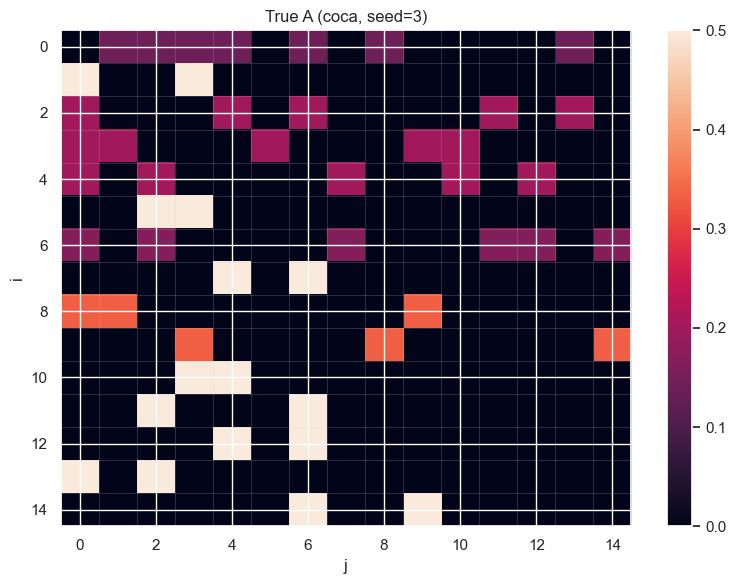

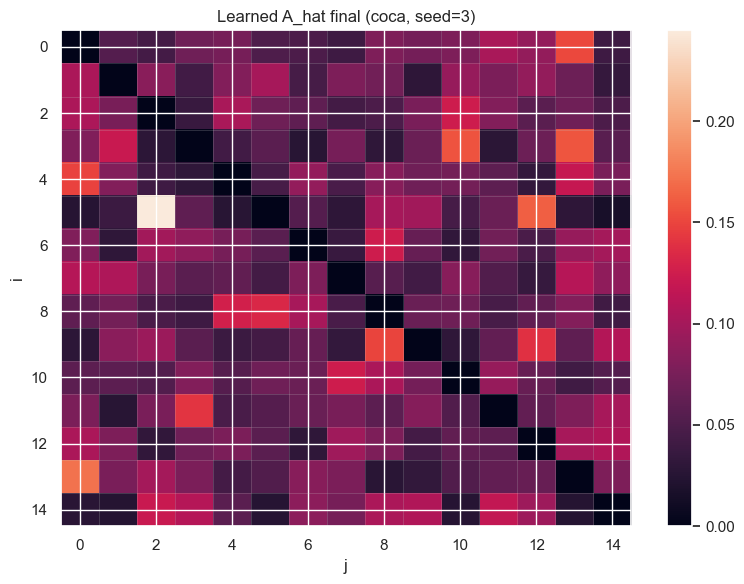


=== AUGMENTED TIME GRID CHECK ===
dt/t_s=0.5, t_campaign=2.0, campaigns=5
learned: T[0], T[-1], monotone: 0.0 10.0 True
oracle : T[0], T[-1], monotone: 0.0 10.0 True
expected final campaign time: 10.0


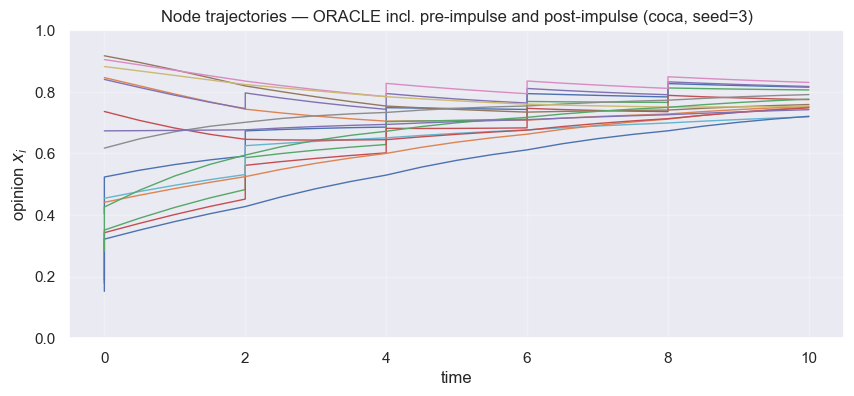

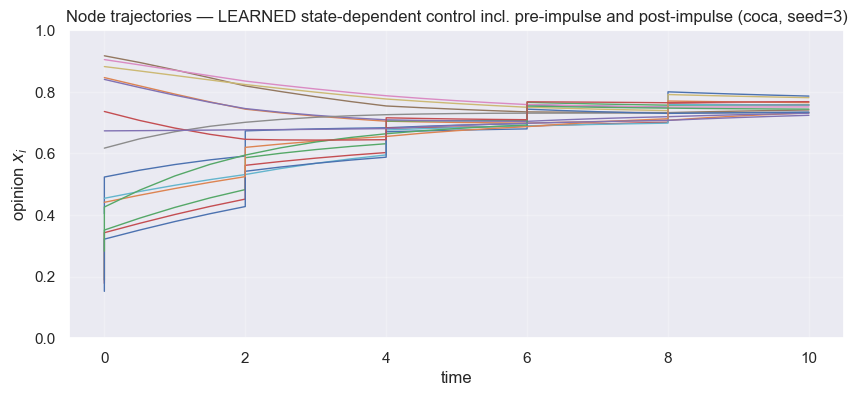


=== FAIRNESS CONVENTION ===
EVAL_ZERO_FIRST_CAMPAIGN: False
campaign-0 action sums: learned= 1.0 oracle= 1.0 uniform= 0.9999999999999999 nocontrol= 0.0
campaign-0 action L_inf learned-oracle: 1.4901161193847656e-08

=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.5000245310743807
L1(v_eff at campaign 0 - v_true): 0.49565271664462074


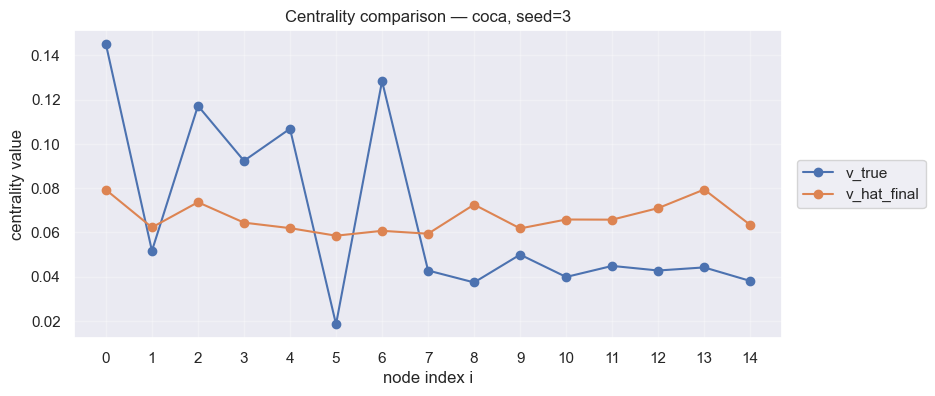

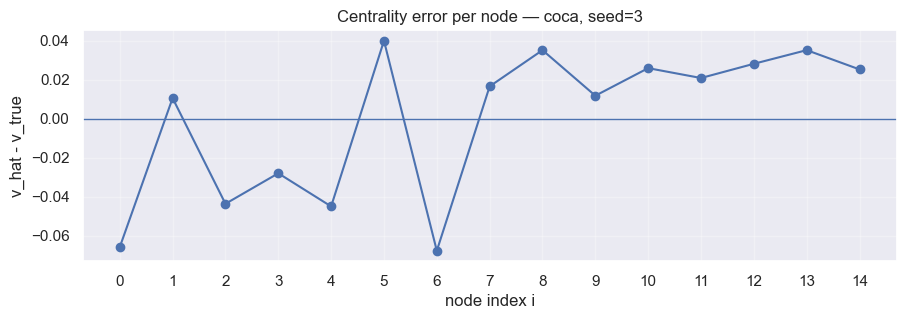

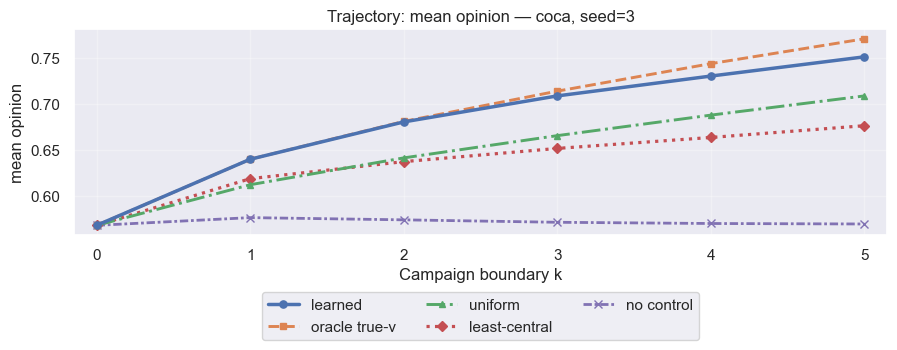


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 6.4290751611295605e-09
learned states[1] vs nocontrol states[1] L_inf: 0.17999329454599458
learned final mean vs uniform final mean: 0.04239193956791798

=== DETAILED ANALYSIS: hegselmannkrause | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999998472630978
row_sum_mean: 0.9999999817460775
row_sum_max: 1.0000000670552254
asym: 0.47768886623

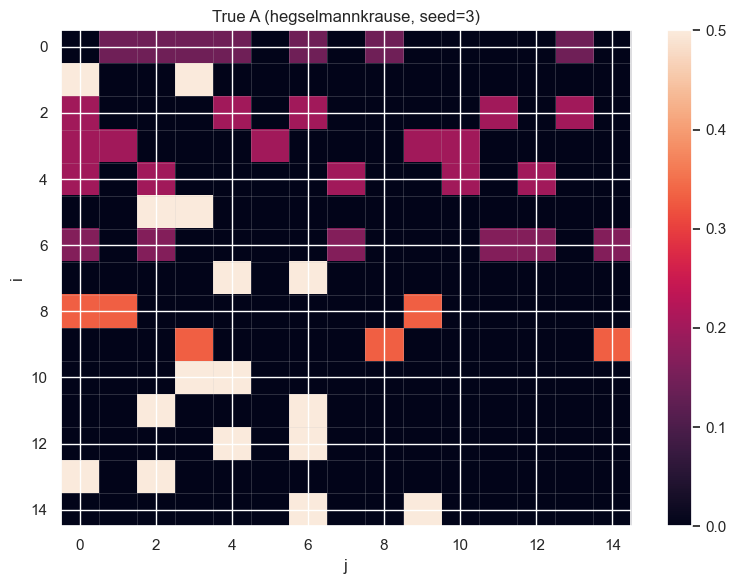

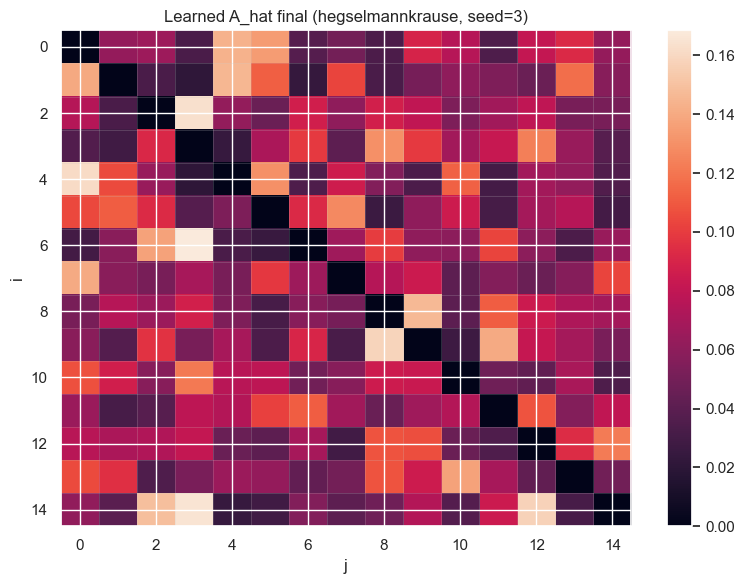


=== AUGMENTED TIME GRID CHECK ===
dt/t_s=0.5, t_campaign=2.0, campaigns=5
learned: T[0], T[-1], monotone: 0.0 10.0 True
oracle : T[0], T[-1], monotone: 0.0 10.0 True
expected final campaign time: 10.0


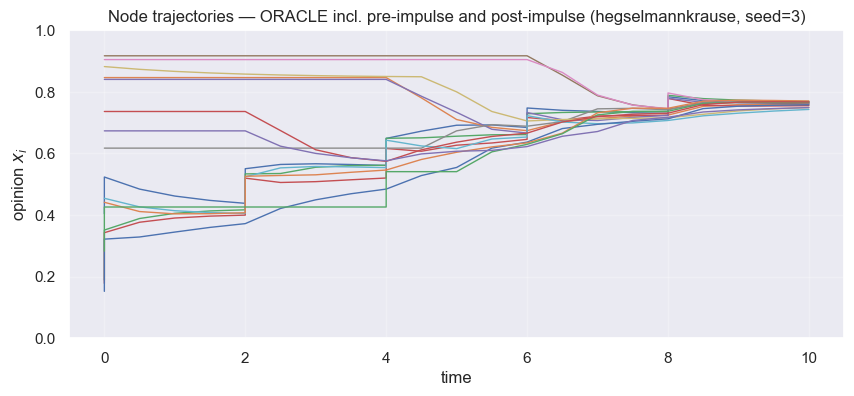

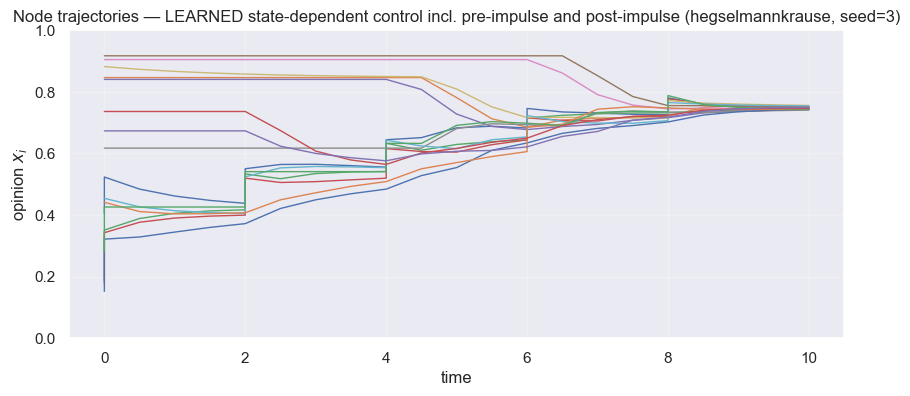


=== FAIRNESS CONVENTION ===
EVAL_ZERO_FIRST_CAMPAIGN: False
campaign-0 action sums: learned= 1.0 oracle= 1.0 uniform= 0.9999999999999999 nocontrol= 0.0
campaign-0 action L_inf learned-oracle: 1.4901161193847656e-08

=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.4842118583997248
L1(v_eff at campaign 0 - v_true): 0.45987661559185966


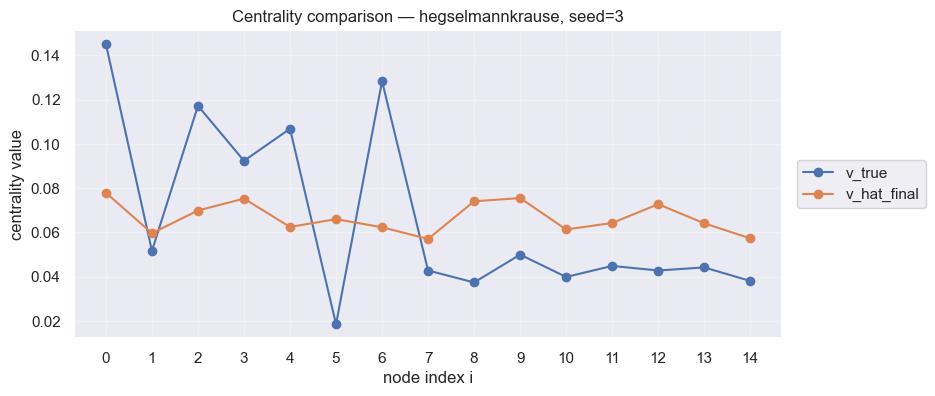

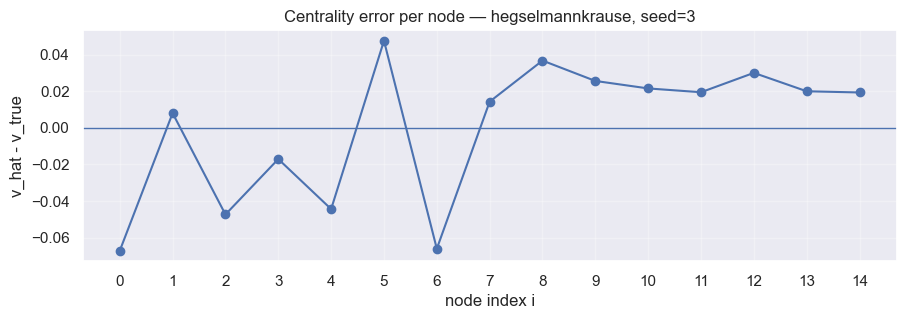

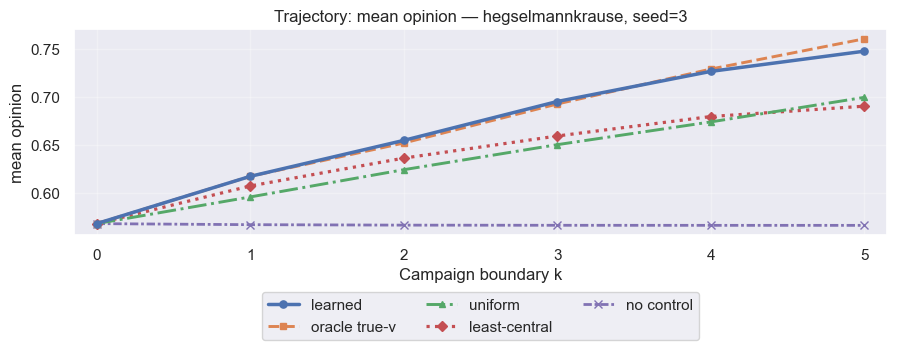


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 1.0689255258711228e-08
learned states[1] vs nocontrol states[1] L_inf: 0.22954860542071392
learned final mean vs uniform final mean: 0.048083295705152795


In [13]:
# =========================================================
# Detailed graph / rollout comparison for the final learned model
# Run for ALL dynamics, as in the previous repeated notebook.
# =========================================================
env_factory = EnvironmentFactory()

for DYNAMICS in list(art_by_dyn.keys()):
    art = art_by_dyn[DYNAMICS]

    A_true = np.asarray(art["A_true"], dtype=float)
    v_true = np.asarray(art["v_true"], dtype=float)
    A_hat_final = np.asarray(art["A_hat_final"], dtype=float)
    v_hat_final = np.asarray(art["v_hat_final"], dtype=float)

    x0_train = np.asarray(art["x0_train"], dtype=float)
    x0_eval = np.asarray(art["x0_eval"], dtype=float)

    states_learn = np.asarray(art["states_learn"], dtype=float)
    states_oracle = np.asarray(art["states_oracle"], dtype=float)
    states_noc = np.asarray(art["states_nocontrol_eval"], dtype=float)
    states_uniform = np.asarray(art["states_uniform_eval"], dtype=float)
    N = states_learn.shape[1]
    K_total = states_learn.shape[0] - 1

    print("\n" + "=" * 80)
    print(f"=== DETAILED ANALYSIS: {DYNAMICS} | SEED {seed_to_plot} ===")
    print("=" * 80)
    print("x0_train:", x0_train)
    print("x0_eval :", x0_eval)

    print("\n=== GRAPH SANITY (TRUE) ===")
    for k, v in graph_sanity(A_true).items():
        print(f"{k}: {v}")

    print("\n=== GRAPH SANITY (LEARNED FINAL) ===")
    for k, v in graph_sanity(A_hat_final).items():
        print(f"{k}: {v}")

    show_matrix_with_cell_grid(
        A_true,
        title=f"True A ({DYNAMICS}, seed={seed_to_plot})",
        grid_alpha=0.25,
        grid_lw=0.6,
    )
    show_matrix_with_cell_grid(
        A_hat_final,
        title=f"Learned A_hat final ({DYNAMICS}, seed={seed_to_plot})",
        grid_alpha=0.25,
        grid_lw=0.6,
    )

    env_template = make_env_with_dynamics(
        env_factory,
        seed=seed_to_plot,
        dynamics_model=DYNAMICS,
    )

    env_learn, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_or, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_nc, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_uni, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )

    le_out = rollout_with_model_derived_control_intermediate(
        env_learn,
        model_by_dyn[DYNAMICS],
        x0_eval,
        K_total,
        B_CAMPAIGN,
        device="cpu",
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )
    or_out = rollout_with_v_intermediate(
        env_or, x0_eval, K_total, B_CAMPAIGN, v_true,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )
    nc_out = rollout_with_v_intermediate(
        env_nc, x0_eval, K_total, B_CAMPAIGN, None,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )
    uni_out = rollout_with_uniform_intermediate(
        env_uni, x0_eval, K_total, B_CAMPAIGN,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )

    order = np.argsort(v_true)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(v_true) + 1)
    v_anti = 1.0 / ranks
    v_anti = v_anti / v_anti.sum()

    env_anti, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    anti_out = rollout_with_v_intermediate(
        env_anti, x0_eval, K_total, B_CAMPAIGN, v_anti,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )

    # Boundary-level states for checks and summary plots
    states_learn_eval = np.asarray(le_out["states"], dtype=float)
    states_or_eval = np.asarray(or_out["states"], dtype=float)
    states_nc_eval = np.asarray(nc_out["states"], dtype=float)
    states_anti_eval = np.asarray(anti_out["states"], dtype=float)
    states_uni_eval = np.asarray(uni_out["states"], dtype=float)

    dt = float(getattr(env_template, "t_s", 1.0))
    t_campaign = float(getattr(env_template, "t_campaign", dt))
    desired_opinion = float(getattr(env_template, "desired_opinion", 1.0))

    X_le, T_le = build_augmented_campaign_trajectory(
        states_learn_eval,
        np.asarray(le_out["actions"], dtype=float),
        le_out["intermediate_states_list"],
        desired_opinion=desired_opinion,
        dt=dt,
        t_campaign=t_campaign,
    )
    X_or, T_or = build_augmented_campaign_trajectory(
        states_or_eval,
        np.asarray(or_out["actions"], dtype=float),
        or_out["intermediate_states_list"],
        desired_opinion=desired_opinion,
        dt=dt,
        t_campaign=t_campaign,
    )

    print("\n=== AUGMENTED TIME GRID CHECK ===")
    print(f"dt/t_s={dt}, t_campaign={t_campaign}, campaigns={K_total}")
    print("learned: T[0], T[-1], monotone:", float(T_le[0]), float(T_le[-1]), bool(np.all(np.diff(T_le) >= -1e-9)))
    print("oracle : T[0], T[-1], monotone:", float(T_or[0]), float(T_or[-1]), bool(np.all(np.diff(T_or) >= -1e-9)))
    print("expected final campaign time:", float(K_total * t_campaign))

    plot_impulse_node_trajectories(
        X_or,
        T_or,
        title=f"Node trajectories — ORACLE incl. pre-impulse and post-impulse ({DYNAMICS}, seed={seed_to_plot})",
    )
    plot_impulse_node_trajectories(
        X_le,
        T_le,
        title=f"Node trajectories — LEARNED state-dependent control incl. pre-impulse and post-impulse ({DYNAMICS}, seed={seed_to_plot})",
    )

    print("\n=== FAIRNESS CONVENTION ===")
    print("EVAL_ZERO_FIRST_CAMPAIGN:", EVAL_ZERO_FIRST_CAMPAIGN)
    print("campaign-0 action sums:",
          "learned=", float(np.asarray(le_out["actions"])[0].sum()),
          "oracle=", float(np.asarray(or_out["actions"])[0].sum()),
          "uniform=", float(np.asarray(uni_out["actions"])[0].sum()),
          "nocontrol=", float(np.asarray(nc_out["actions"])[0].sum()))
    print("campaign-0 action L_inf learned-oracle:",
          float(np.max(np.abs(np.asarray(le_out["actions"])[0] - np.asarray(or_out["actions"])[0]))))

    print("\n=== INITIAL-STATE / IMPULSE CHECK ===")
    print("L_inf(common x0_eval - learned boundary state[0]):", float(np.max(np.abs(x0_eval - states_learn_eval[0]))))
    print("L_inf(common x0_eval - oracle boundary state[0]):", float(np.max(np.abs(x0_eval - states_or_eval[0]))))
    print("L_inf(learned boundary state[0] - oracle boundary state[0]):", float(np.max(np.abs(states_learn_eval[0] - states_or_eval[0]))))
    print("Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.")

    print("\n=== CENTRALITY COMPARISON (by node index) ===")
    print("L1(v_hat_final - v_true):", float(np.sum(np.abs(v_hat_final - v_true))))
    if art.get("learned_effective_centralities"):
        v_eff0 = np.asarray(art["learned_effective_centralities"][0], dtype=float)
        print("L1(v_eff at campaign 0 - v_true):", float(np.sum(np.abs(v_eff0 - v_true))))

    idx = np.arange(N)
    diff = v_hat_final - v_true

    fig, ax = plt.subplots(figsize=(10.5, 4))
    ax.plot(idx, v_true, marker="o", label="v_true")
    ax.plot(idx, v_hat_final, marker="o", label="v_hat_final")
    ax.set_xlabel("node index i")
    ax.set_ylabel("centrality value")
    ax.set_title(f"Centrality comparison — {DYNAMICS}, seed={seed_to_plot}")
    ax.set_xticks(idx)
    ax.grid(True, alpha=0.3)
    _legend_outside(ax)
    fig.subplots_adjust(right=0.80)
    plt.show()

    fig, ax = plt.subplots(figsize=(10.5, 3))
    ax.axhline(0.0, linewidth=1)
    ax.plot(idx, diff, marker="o")
    ax.set_xlabel("node index i")
    ax.set_ylabel("v_hat - v_true")
    ax.set_title(f"Centrality error per node — {DYNAMICS}, seed={seed_to_plot}")
    ax.set_xticks(idx)
    ax.grid(True, alpha=0.3)
    plt.show()

    mean_learn = states_learn_eval.mean(axis=1)
    mean_or = states_or_eval.mean(axis=1)
    mean_nc = states_nc_eval.mean(axis=1)
    mean_uni = states_uni_eval.mean(axis=1)
    mean_anti = states_anti_eval.mean(axis=1)

    plot_mean_baseline_comparison(
        {
            "learned": mean_learn,
            "oracle true-v": mean_or,
            "uniform": mean_uni,
            "least-central": mean_anti,
            "no control": mean_nc,
        },
        title=f"Trajectory: mean opinion — {DYNAMICS}, seed={seed_to_plot}",
    )

    print("\n=== CAMPAIGN-0 OVERLAP CHECK ===")
    print(
        "learned states[1] vs oracle states[1] L_inf:",
        float(np.max(np.abs(states_learn_eval[1] - states_or_eval[1]))),
    )
    print(
        "learned states[1] vs nocontrol states[1] L_inf:",
        float(np.max(np.abs(states_learn_eval[1] - states_nc_eval[1]))),
    )

    print("learned final mean vs uniform final mean:",
          float(mean_learn[-1] - mean_uni[-1]))
